# Fake Bills Detection using K-Nearest Neighbors (KNN)

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix ,accuracy_score


## Load the Dataset

In [2]:
df = pd.read_csv('fake_bills.csv',sep=';')
df.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


## Explore the Dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


In [4]:
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


## Data Cleaning & Preprocessing

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

## Handle Missing Values

In [7]:
df["margin_low"] = df["margin_low"].fillna(df["margin_low"].mean())

In [8]:
df.isna().sum()

is_genuine      0
diagonal        0
height_left     0
height_right    0
margin_low      0
margin_up       0
length          0
dtype: int64

## Feature Selection

In [9]:
sc = StandardScaler()
X = sc.fit_transform(df.drop('is_genuine',axis=1))
y = df['is_genuine']


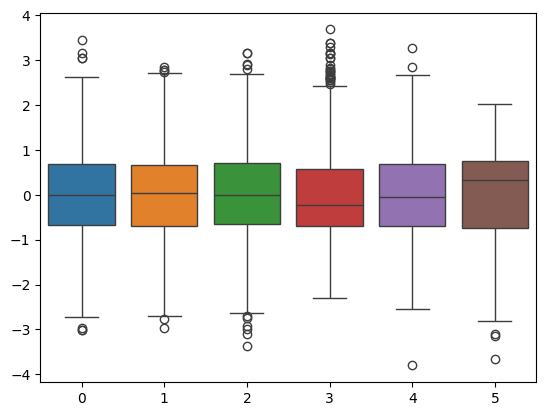

In [10]:
sns.boxplot(X)
plt.show()

In [11]:
pd.DataFrame(X)

,0,1,2,3,4,5
0,-0.486540,2.774123,3.163240,0.051931,-1.128325,0.173651
1,-1.633729,-2.236535,-0.799668,-1.092495,-0.696799,0.471666
2,2.397823,1.504756,-1.291191,-0.131177,-0.912562,0.551901
3,-1.961498,-0.399294,0.060498,-1.321380,-0.610494,0.953075
4,-0.748754,0.836669,-1.414072,-0.680502,1.417677,-0.158750
...,...,...,...,...,...,...
1495,-0.683201,1.170713,0.767063,-0.100659,-0.265273,-1.602978
1496,0.758981,2.005822,1.596509,1.196357,0.942999,-1.958303
1497,-0.519316,-0.065250,0.613462,1.562573,0.899846,-0.835016
1498,0.332882,0.836669,0.429141,1.043767,1.331372,-0.491152


## Split Dataset into Training and Testing Sets

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Train the KNN Model

In [24]:
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[bool](2,)","[False, True]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## Make Predictions

In [25]:
ypred = knn.predict(X_test)
ypred

array([False, False,  True,  True,  True,  True, False,  True, False,
        True,  True, False,  True, False,  True, False, False,  True,
        True,  True, False, False, False, False, False,  True, False,
       False, False,  True, False,  True, False, False,  True,  True,
        True,  True, False,  True, False,  True, False,  True, False,
        True,  True,  True,  True,  True,  True,  True, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True, False, False,  True,  True,  True, False,
        True,  True,  True, False, False,  True,  True,  True, False,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True, False,  True, False, False,  True,  True, False,
       False,  True,

## Evaluate Model Performance

In [26]:
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

       False       1.00      0.98      0.99       110
        True       0.99      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [27]:
confusion_matrix(y_test,ypred)

array([[108,   2],
       [  0, 190]])

In [28]:
accuracy_score(y_test,ypred)

0.9933333333333333

In [29]:
print(f'Train Score: {knn.score(X_train,y_train)}')
print(f'Test Score: {knn.score(X_test,y_test)}') 

Train Score: 0.9933333333333333
Test Score: 0.9933333333333333


## Find Optimal K Value

In [30]:
# Finding the optimal K value
train_acc = []
test_acc = []
for i in range(2,20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    train_acc.append(knn.score(X_train,y_train))
    test_acc.append(knn.score(X_test,y_test))

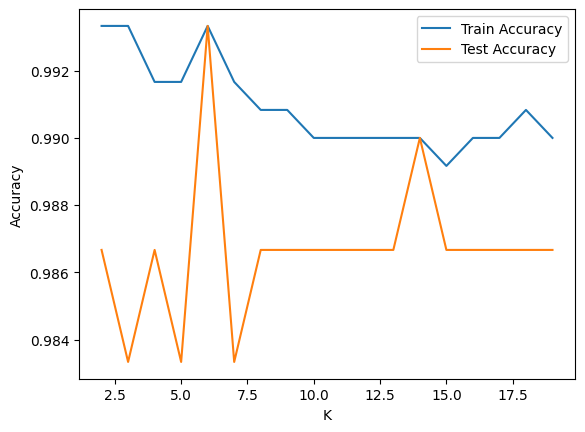

In [31]:
plt.plot(range(2,20), train_acc, label='Train Accuracy')
plt.plot(range(2,20), test_acc, label='Test Accuracy')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [32]:
select = abs(train_acc[0] - test_acc[0])
for i in range(2,20):
    print(f'K={i}', abs(train_acc[i-2] - test_acc[i-2]))
    if select > abs(train_acc[i-2] - test_acc[i-2]):
        select = abs(train_acc[i-2] - test_acc[i-2])
        k = i


print("--"*25)
print(f'Best K: {k}, Difference: {select}')

K=2 0.006666666666666599
K=3 0.010000000000000009
K=4 0.0050000000000000044
K=5 0.008333333333333415
K=6 0.0
K=7 0.008333333333333415
K=8 0.004166666666666652
K=9 0.004166666666666652
K=10 0.0033333333333332993
K=11 0.0033333333333332993
K=12 0.0033333333333332993
K=13 0.0033333333333332993
K=14 0.0
K=15 0.0024999999999999467
K=16 0.0033333333333332993
K=17 0.0033333333333332993
K=18 0.004166666666666652
K=19 0.0033333333333332993
--------------------------------------------------
Best K: 6, Difference: 0.0


## Results and Observations

The K-Nearest Neighbors (KNN) model was successfully trained to classify fake and genuine bills. After testing multiple K values, the optimal value was found to be **K = 6**. This value provided a good balance between model stability and prediction performance. Feature scaling and selecting the correct K value improved the overall classification results.

## Conclusion

In this project, a K-Nearest Neighbors (KNN) classification model was developed to detect whether a bill is genuine or fake. The workflow included data loading, preprocessing, feature scaling, model training, prediction, and evaluation.

The model demonstrated that KNN can effectively classify bills based on feature similarity. Feature scaling played an important role in improving performance because KNN relies on distance calculations.

Future improvements may include hyperparameter tuning, cross-validation, using pipelines to prevent data leakage, and comparing KNN with other algorithms such as Random Forest and XGBoost.

# Final Accuracy Achieved: 99%